# 1. Prompt engineering 
Prompt engineering is about taking a prompt you've written and improving it to get more reliable, higher-quality outputs. This process involves iterative refinement. 
1. Starting with a basic prompt, 
2. evaluating its performance, then 
3. systematically applying engineering techniques to improve it.

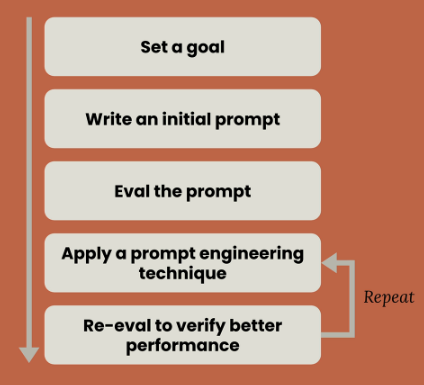

You repeat the last two steps until you're satisfied with the performance. Each iteration should show measurable improvement in your evaluation scores.

## Setting up the Evaluation Pipeline
we'll work with a practical example: creating a prompt that generates one-day meal plans for athletes. The prompt needs to take into account:
1. athlete's height
2. weight
3. goals
4. dietary restrictions
5. then produce a comprehensive meal plan.

The evaluation setup uses:
1. `PromptEvaluator` class that handles dataset generation and model grading.
2. You can control concurrency with the `max_concurrent_tasks` parameter

* *Note: We'll start wtha  low concurrency value of 3 to avoid rate limit errors.*

### Generating Test Data

In [2]:
dataset = evaluator.generate_dataset(
    task_description="Write a compact, concise 1 day meal plan for a single athlete",
    prompt_inputs_spec={
        "height": "Athlete's height in cm",
        "weight": "Athlete's weight in kg", 
        "goal": "Goal of the athlete",
        "restrictions": "Dietary restrictions of the athlete"
    },
    output_file="dataset.json",
    num_cases=3
)

NameError: name 'evaluator' is not defined

* *Note: Keep the number of test cases low (2-3) during development to speed up your iteration cycle. You can increase this for final validation.*

### Writing Your Initial Prompt

Start with a simple, naive prompt to establish a baseline.

In [ ]:
def run_prompt(prompt_inputs):
    prompt = f"""
What should this person eat?

- Height: {prompt_inputs["height"]}
- Weight: {prompt_inputs["weight"]}
- Goal: {prompt_inputs["goal"]}
- Dietary restrictions: {prompt_inputs["restrictions"]}
"""
    
    messages = []
    add_user_message(messages, prompt)
    return chat(messages)

When running your evaluation, you can specify additional criteria that the grading model should consider:

In [ ]:
results = evaluator.run_evaluation(
    run_prompt_function=run_prompt,
    dataset_file="dataset.json",
    extra_criteria="""
The output should include:
- Daily caloric total
- Macronutrient breakdown  
- Meals with exact foods, portions, and timing
"""
)

### Analyzing Results
* After running an evaluation, you'll get both a numerical score and a detailed HTML report. The report shows you exactly how each test case performed, including the model's reasoning for each score.
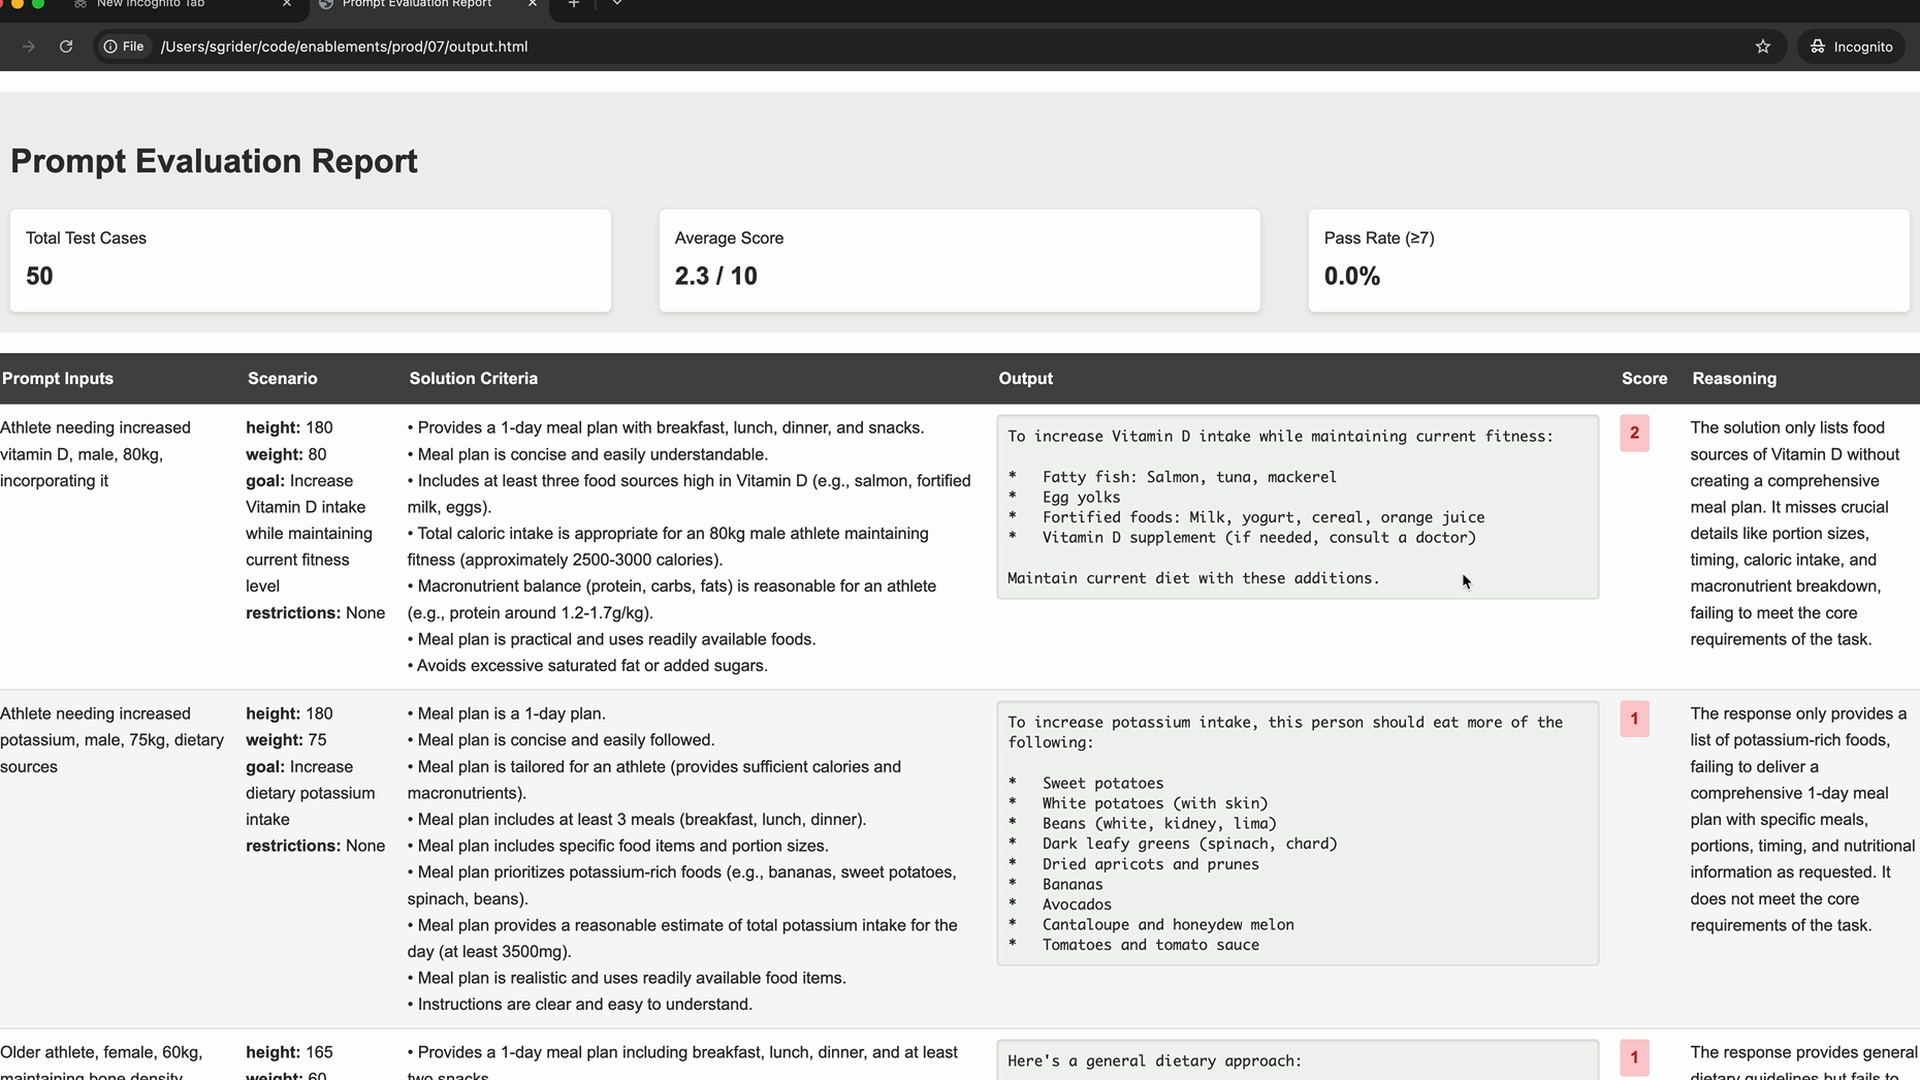
* Don't be discouraged by low initial scores - a score of 2.3 out of 10 is typical for a first attempt. The goal is to see consistent improvement as you apply engineering techniques.
* Use this feedback to guide your next iteration.

# 2. Being Clear and Direct

* **The first line of your prompt is the most important part of your entire request. This is where you set the stage for everything that follows, and getting it right can dramatically improve your results.**

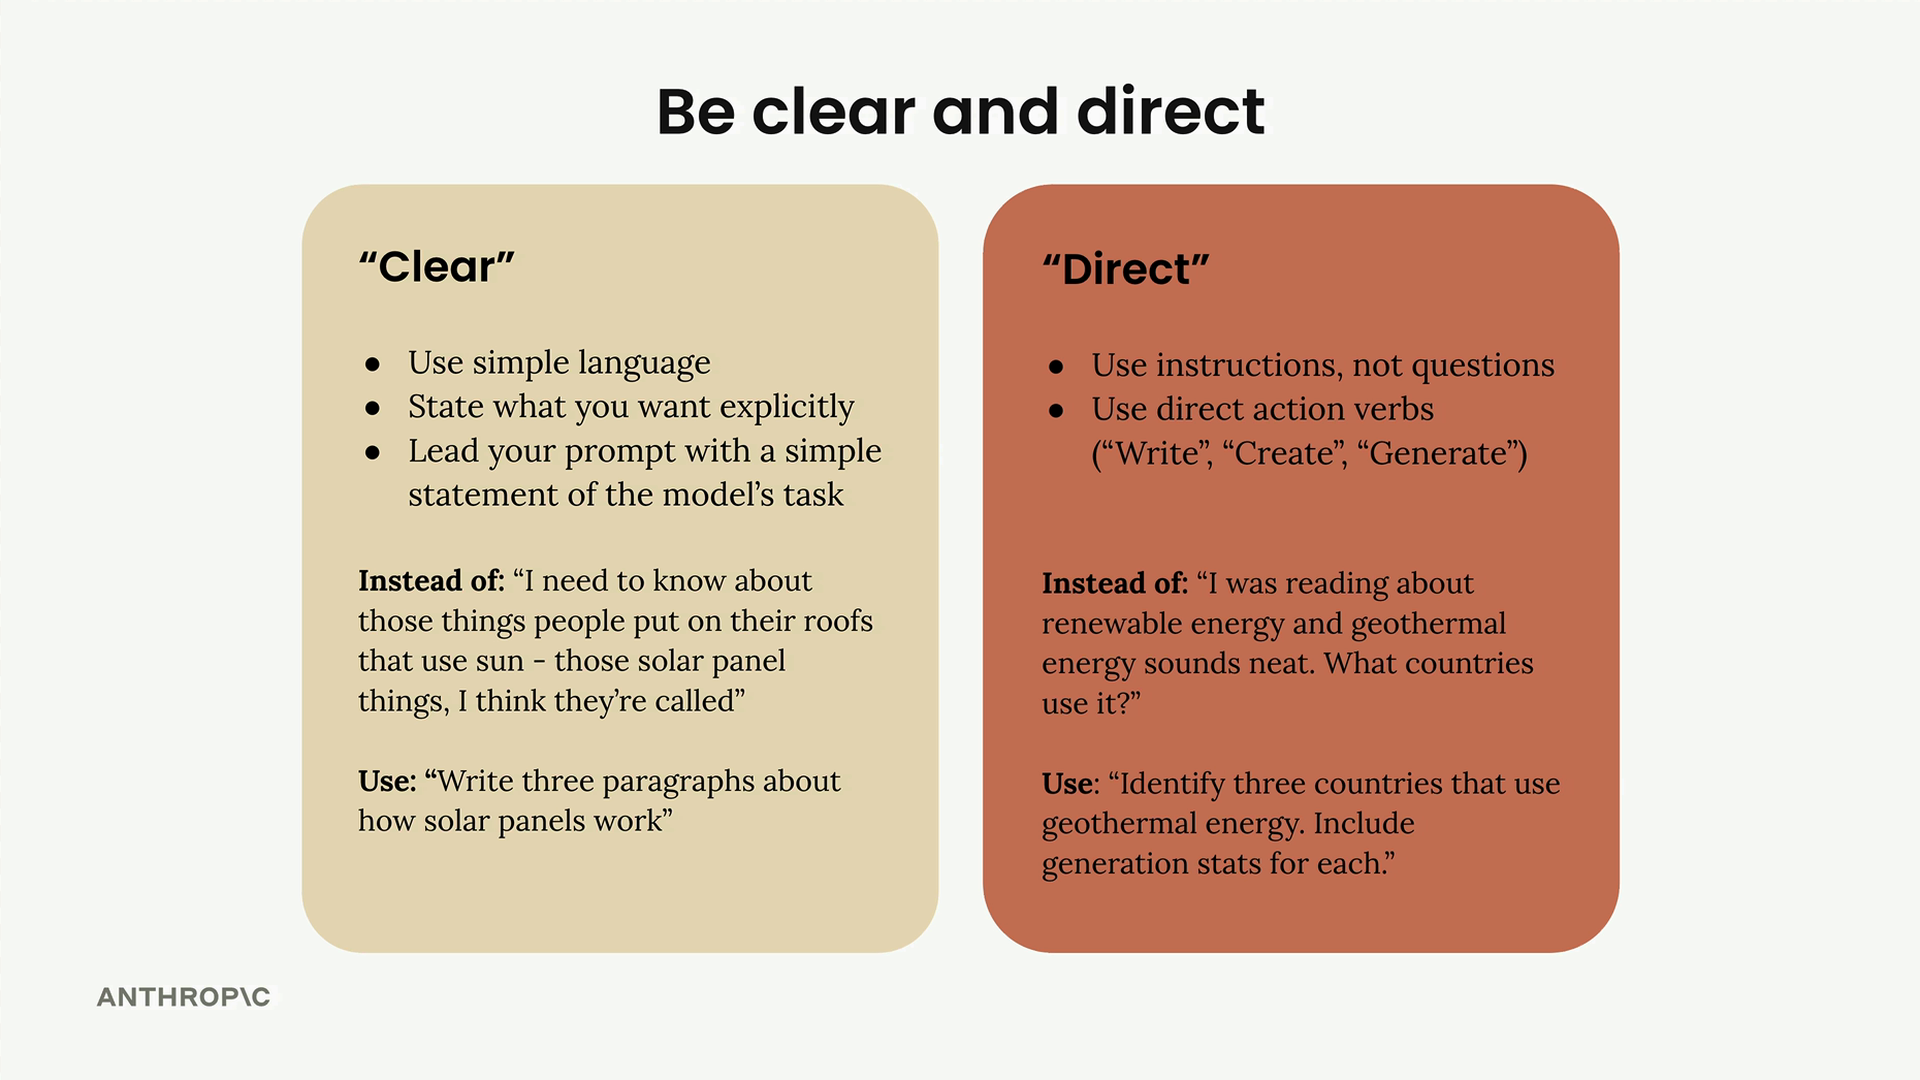

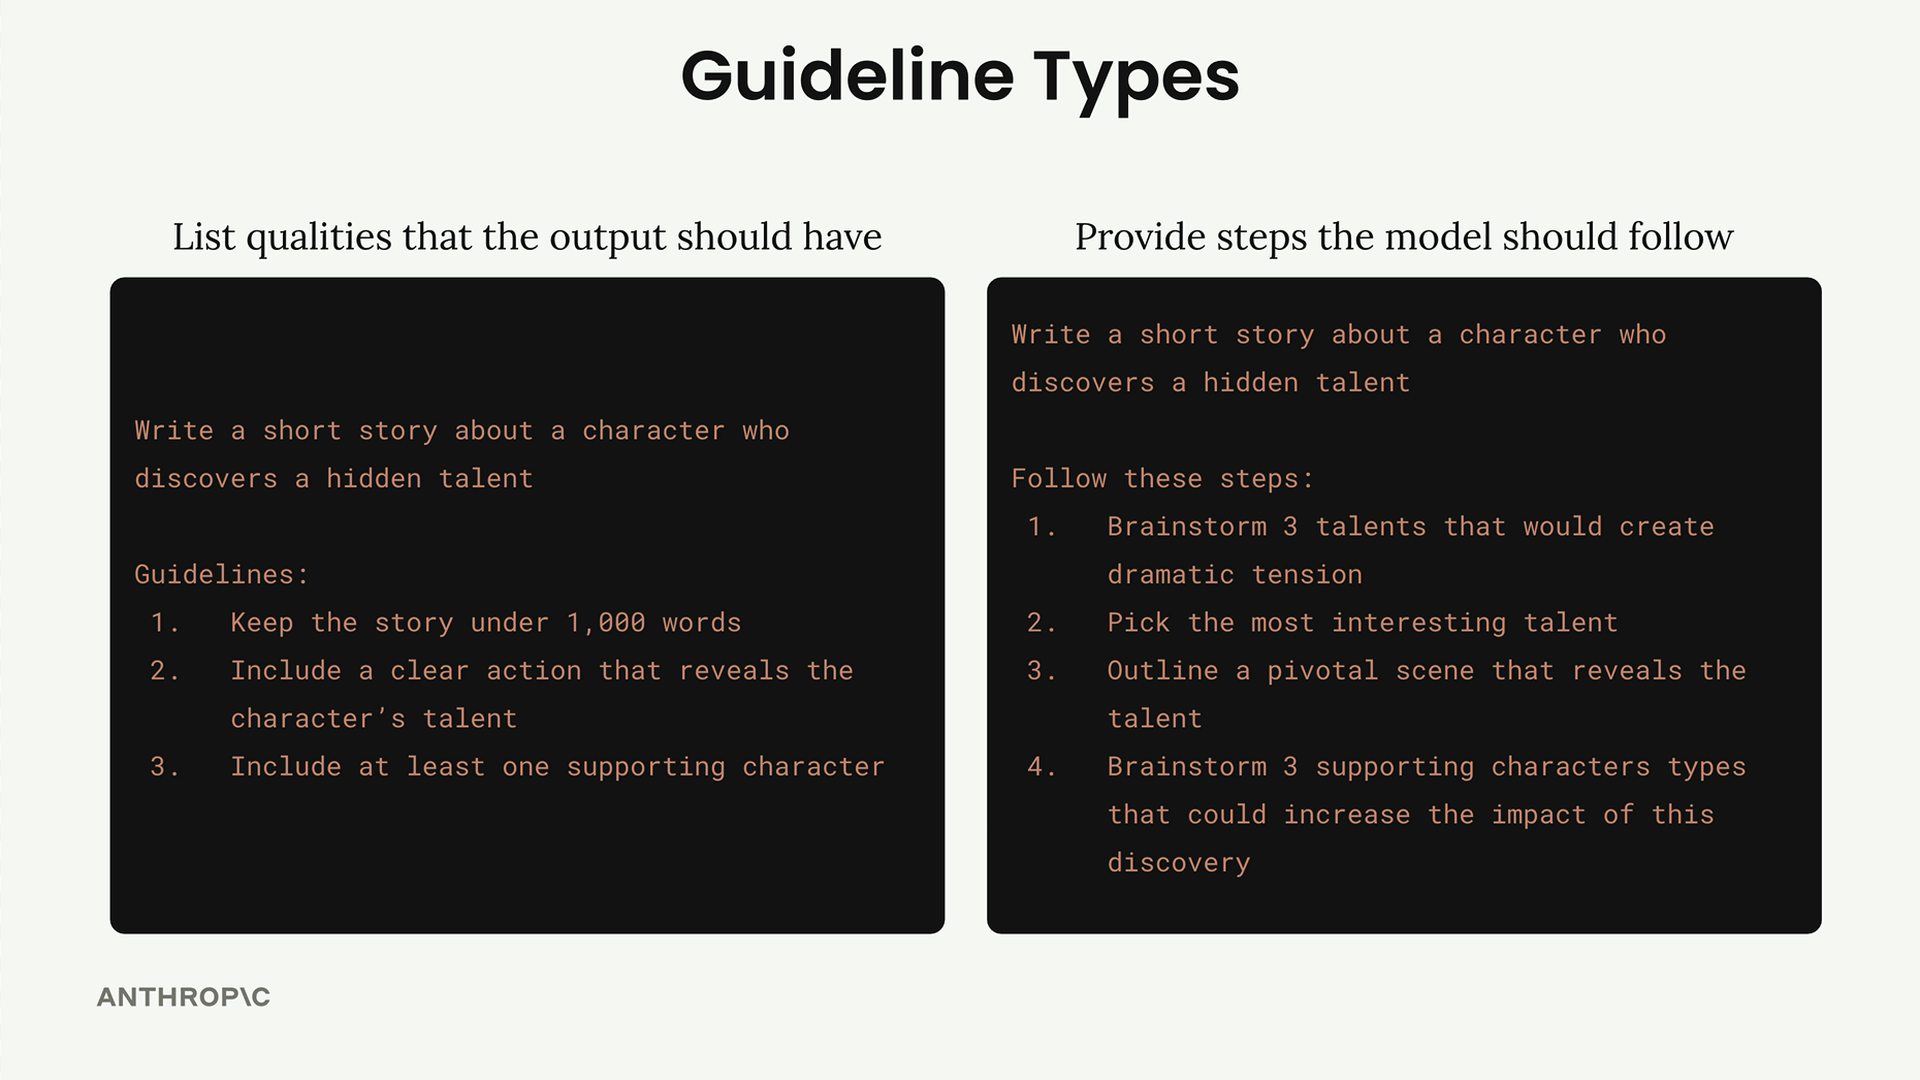

**The difference that specificity makes is dramatic**. In testing a meal planning prompt, adding guidelines improved the evaluation score from 3.92 to 7.86 - more than doubling the quality of the output simply by telling Claude exactly what elements to include.

#### Always Use Output Guidelines
You should include quality guidelines in almost every prompt you write. They're your safety net for getting consistent, useful results.

#### Use Process Steps For Complex Problems
Add step-by-step instructions when you're dealing with:

* Troubleshooting complex problems  
* Decision-making scenarios  
* Critical thinking tasks  
* Any situation where you want Claude to consider multiple angles  

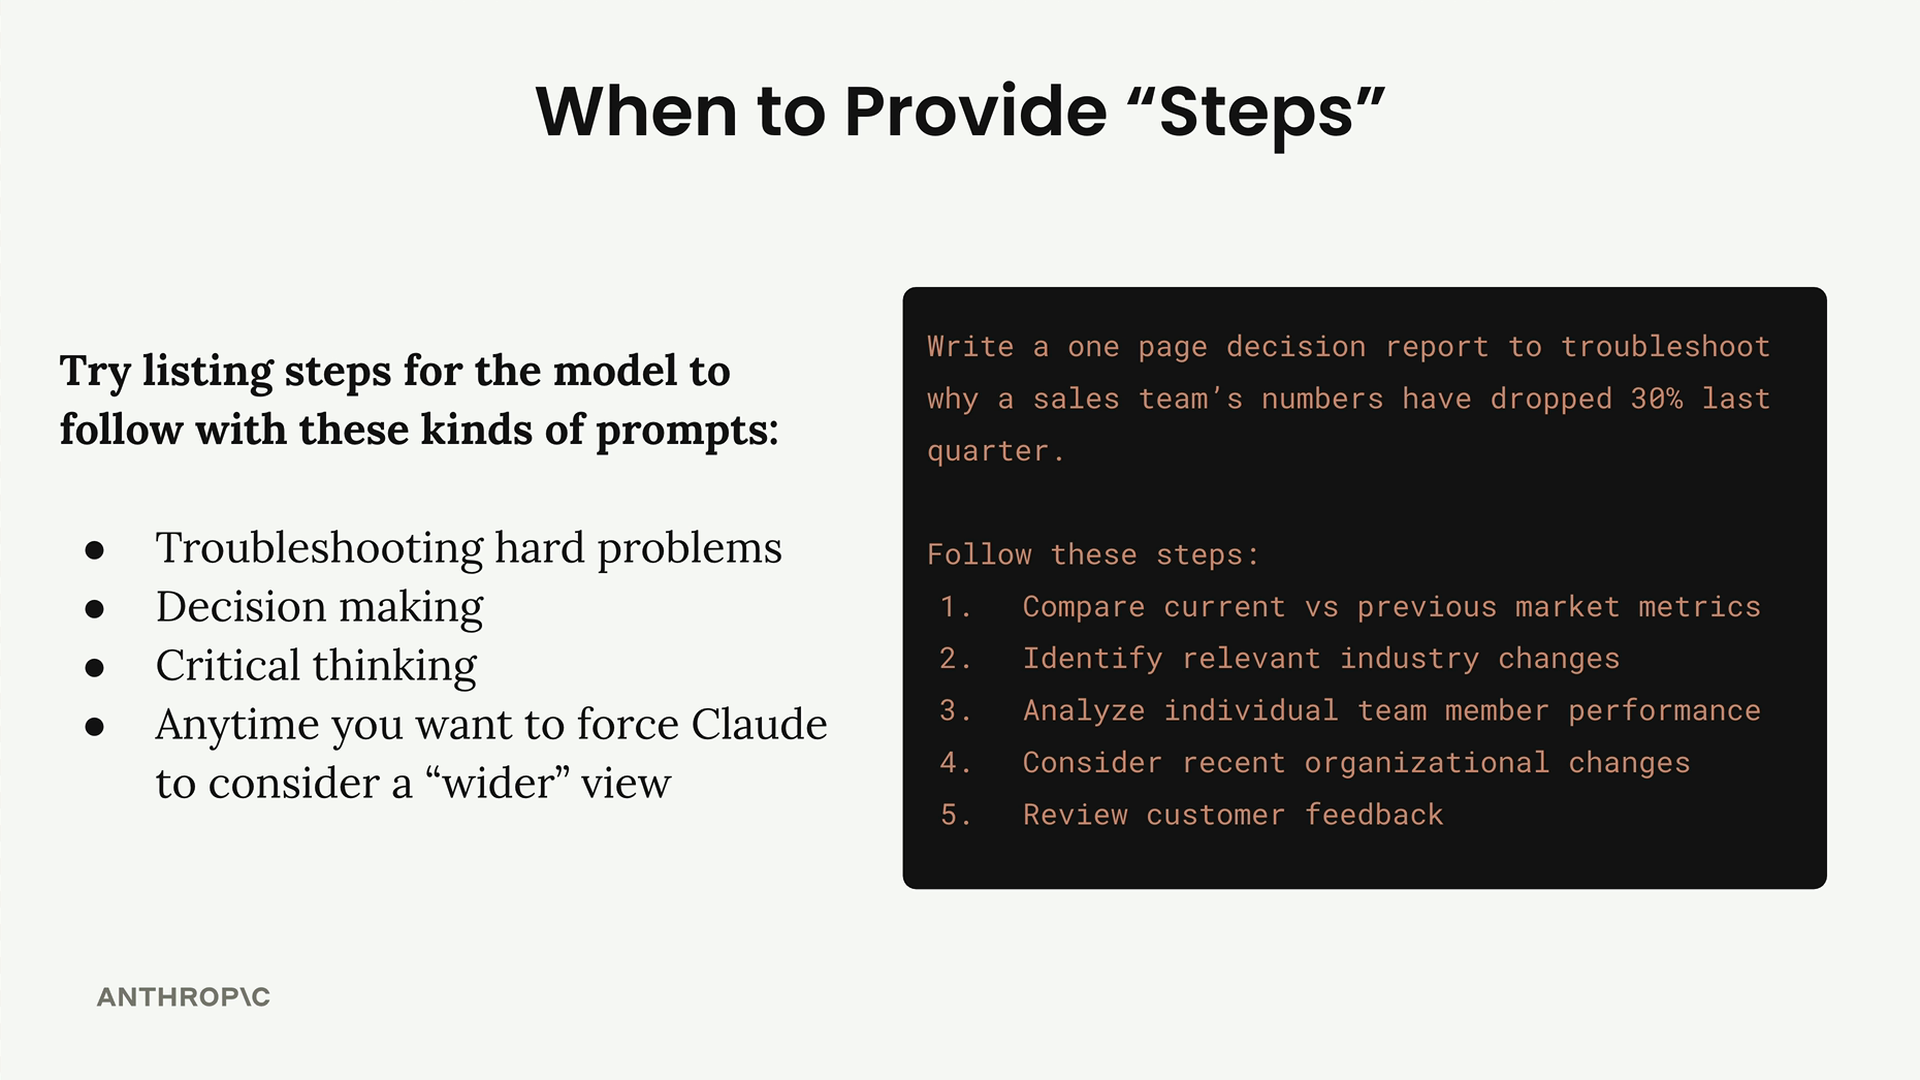

# Structure with XML tags

XML tags provide a simple way to add structure and clarity to your prompts, especially when you're interpolating large amounts of data.

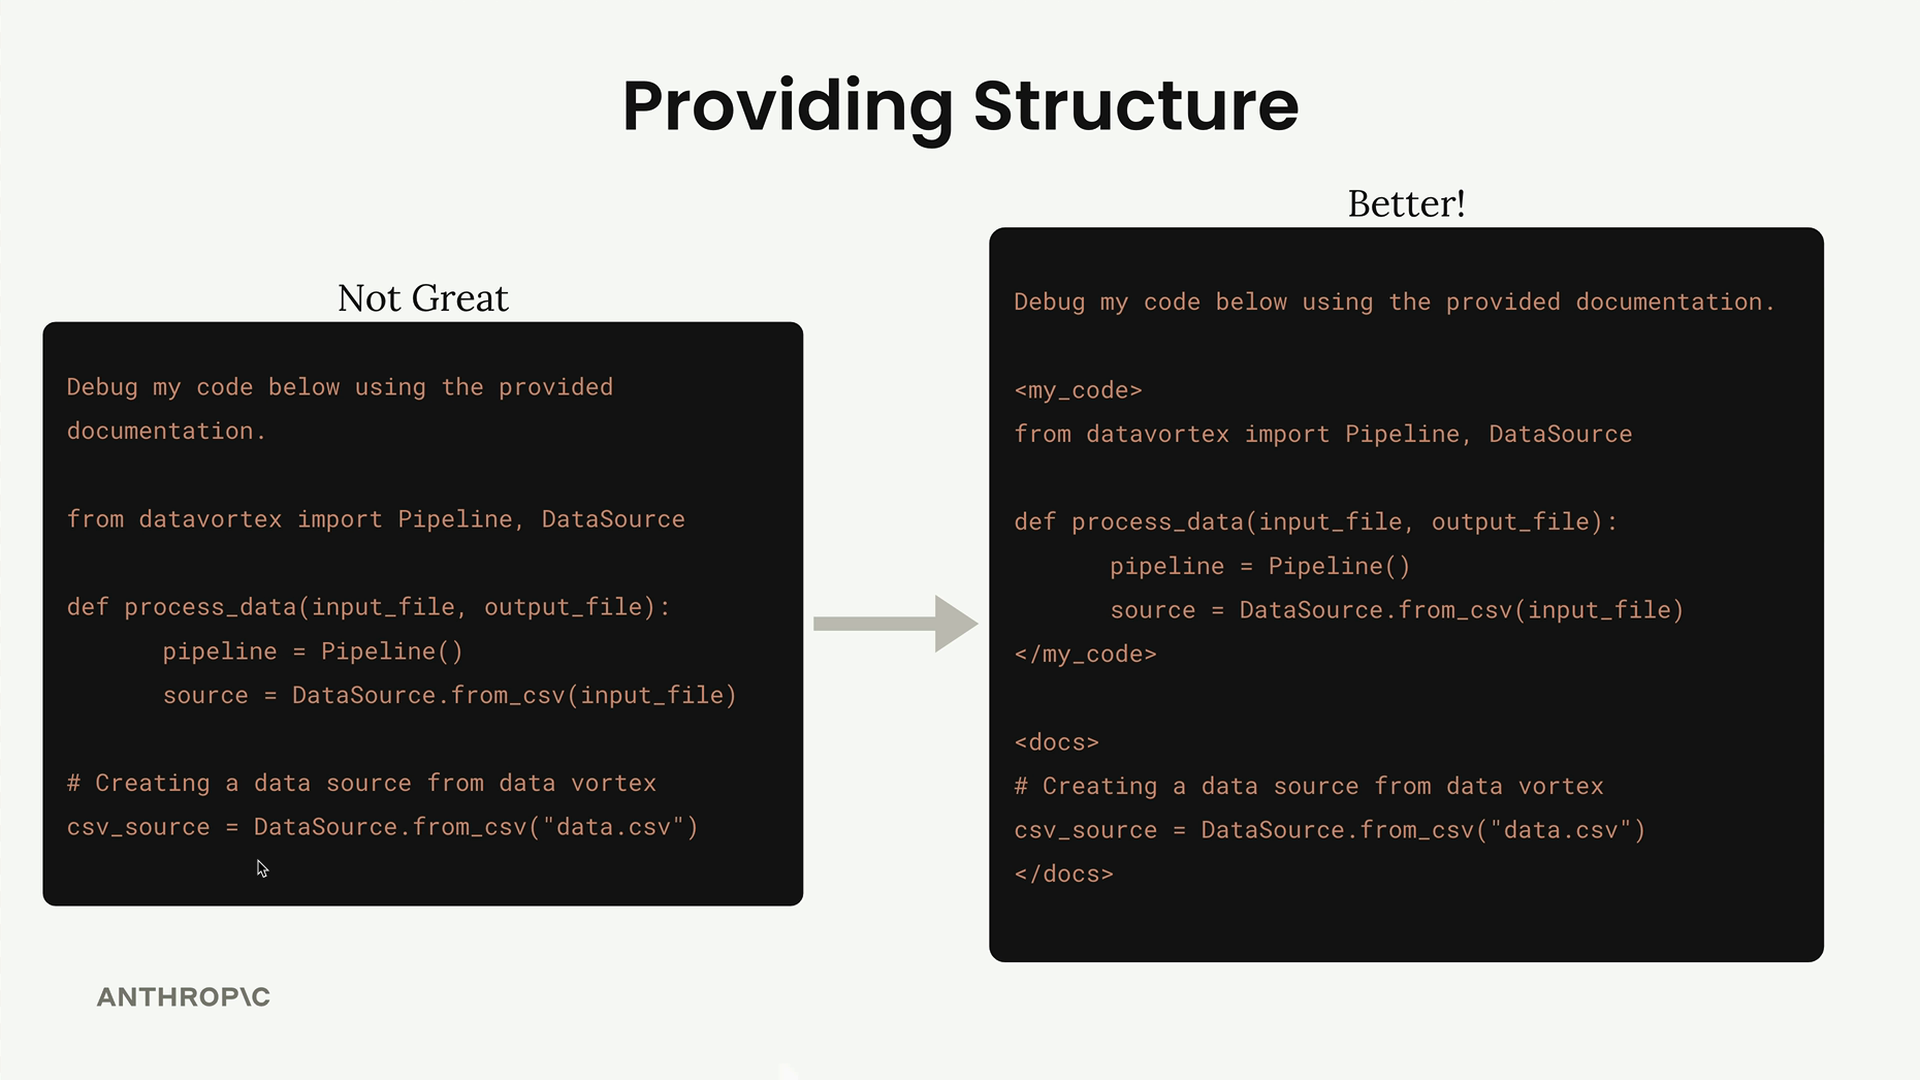

You don't need to use official XML tags. Create descriptive names that make sense for your content:

* `<sales_records>` is better than <data>
* `<athlete_information>` clearly identifies user details
* `<my_code> and <docs>` separate different types of content
#### Real World Application:

```
<athlete_information>
- Height: 6'2"
- Weight: 180 lbs
- Goal: Build muscle
- Dietary restrictions: Vegetarian
</athlete_information>

Generate a meal plan based on the athlete information above.
```

# 3. Providing Examples

**Providing examples in your prompts is one of the most effective prompt engineering techniques you'll use.**   
This approach, known as **"one-shot"** or **"multi-shot"** prompting, involves giving Claude sample input/output pairs to guide its responses.

#### How Examples Work
Let's look at a sentiment analysis example. Say you want Claude to categorize whether a tweet is positive or negative
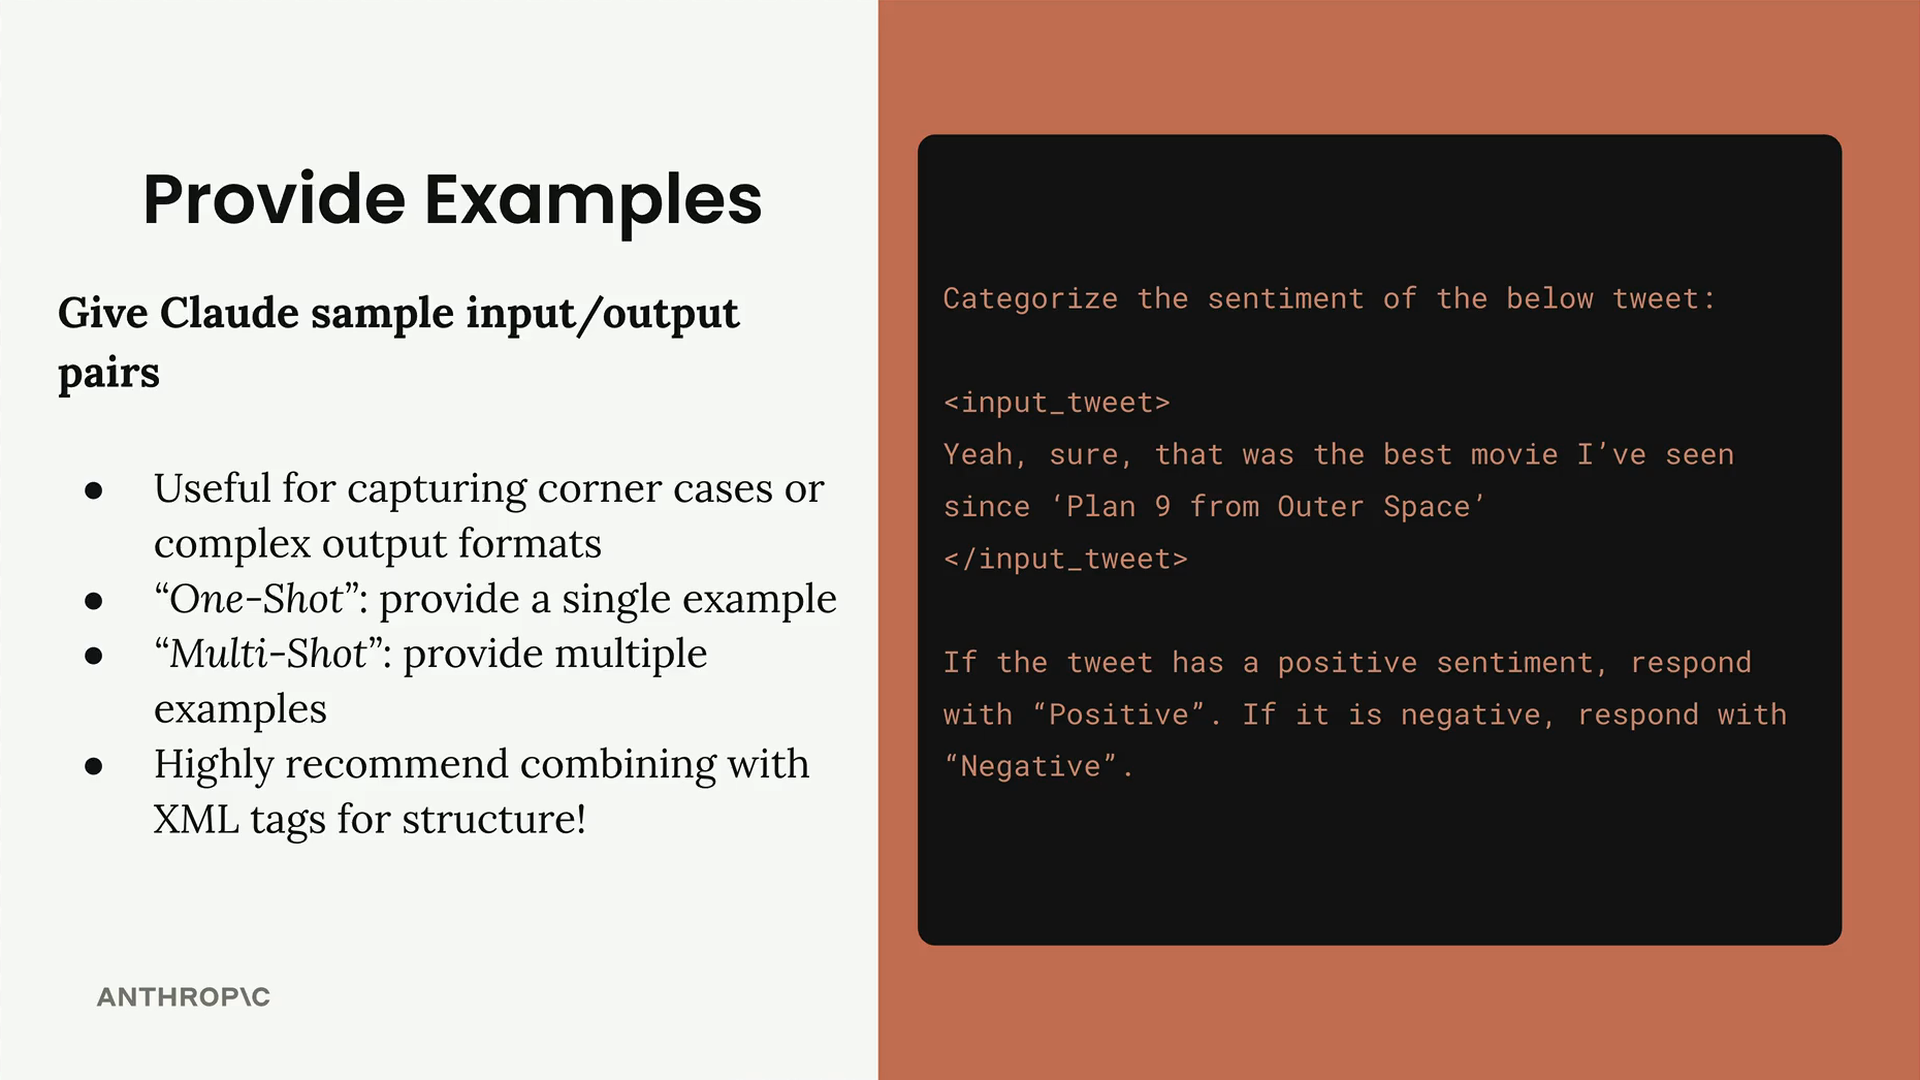

#### Adding Examples to Handle Corner Cases
To solve this, you can add examples that show Claude how to handle tricky cases:
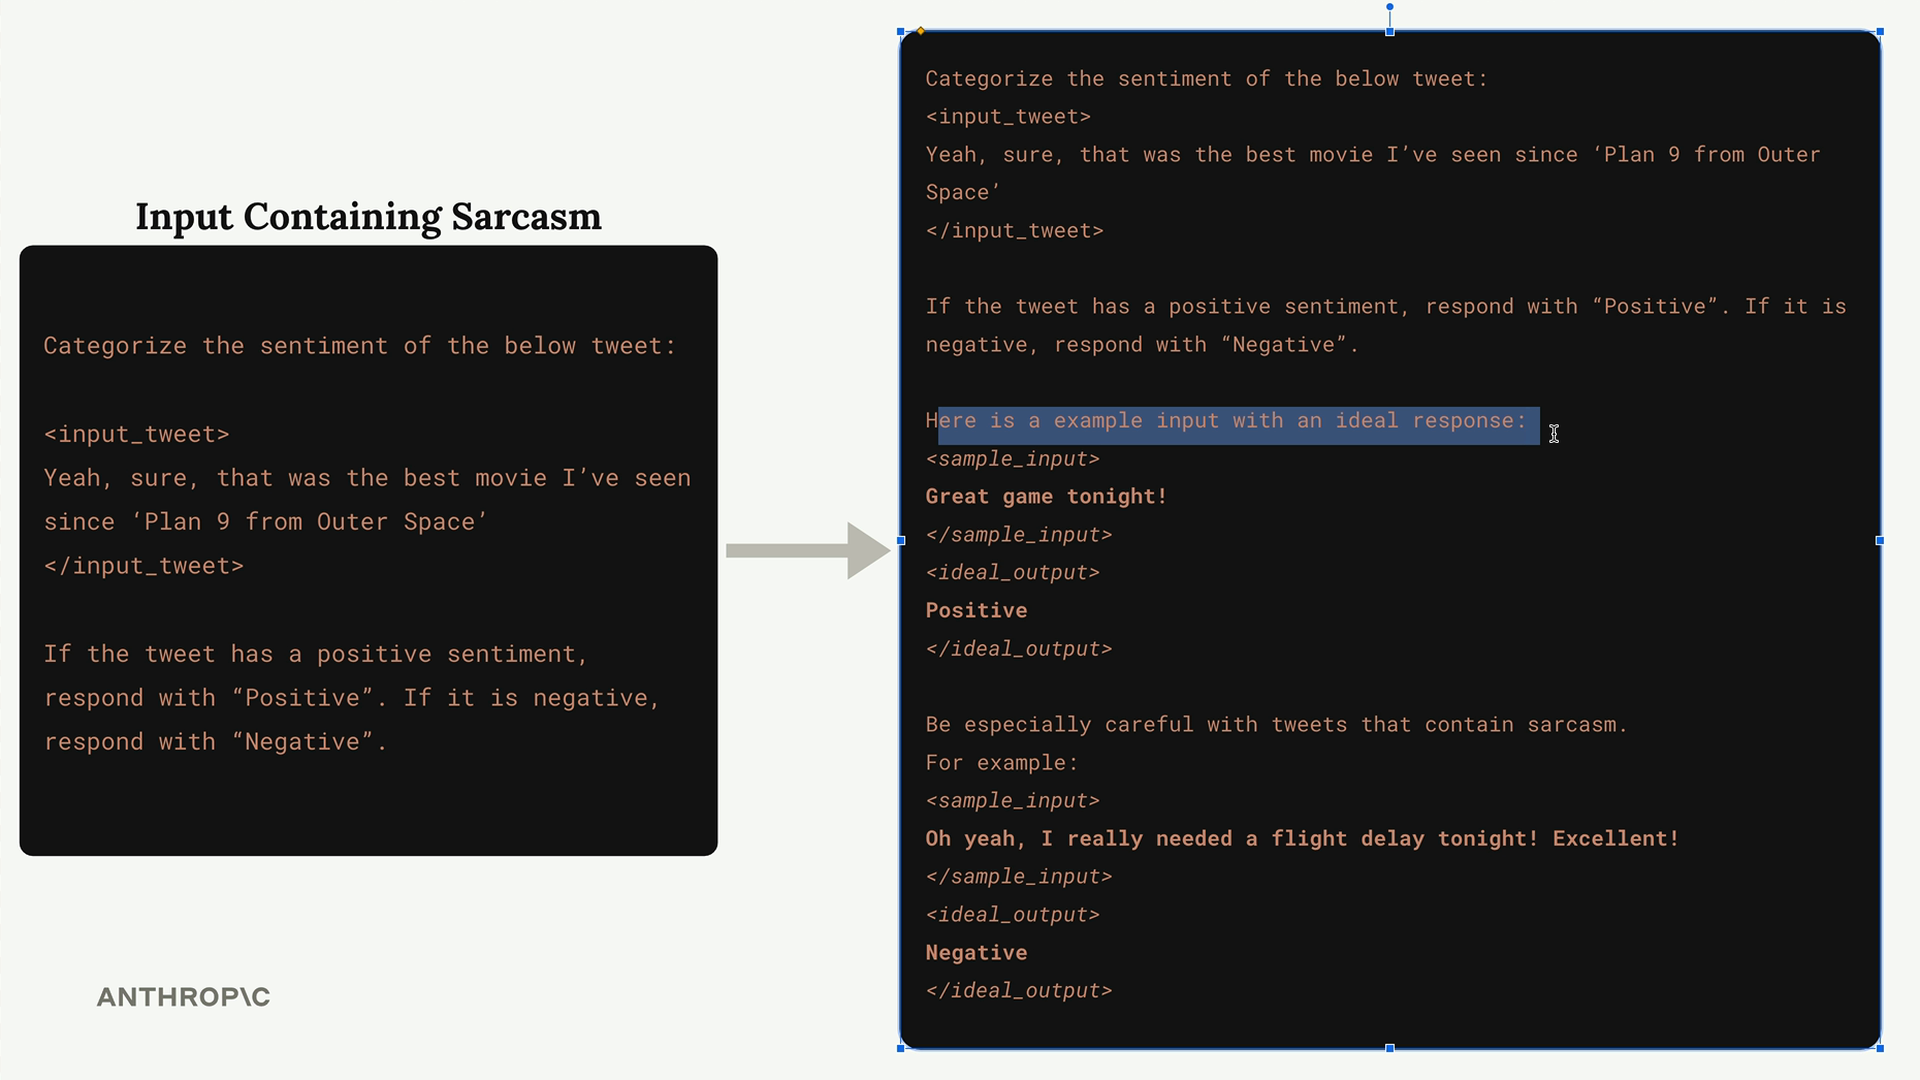


#### When to Use Examples
* Capturing corner cases or edge scenarios
* Defining complex output formats (like specific JSON structures)
* Showing the exact style or tone you want
* Demonstrating how to handle ambiguous inputs

#### "One Shot" vs "Multi-Shot" Examples

* **One-Shot:** Provide a single example to establish the pattern

* **Multi-Shot:** Provide multiple examples to cover different scenarios

Use multi-shot when you need to handle various edge cases or want to show different types of valid responses.

#### Finding Good Examples from Evaluations

When running prompt evaluations, look for your highest-scoring outputs to use as examples:

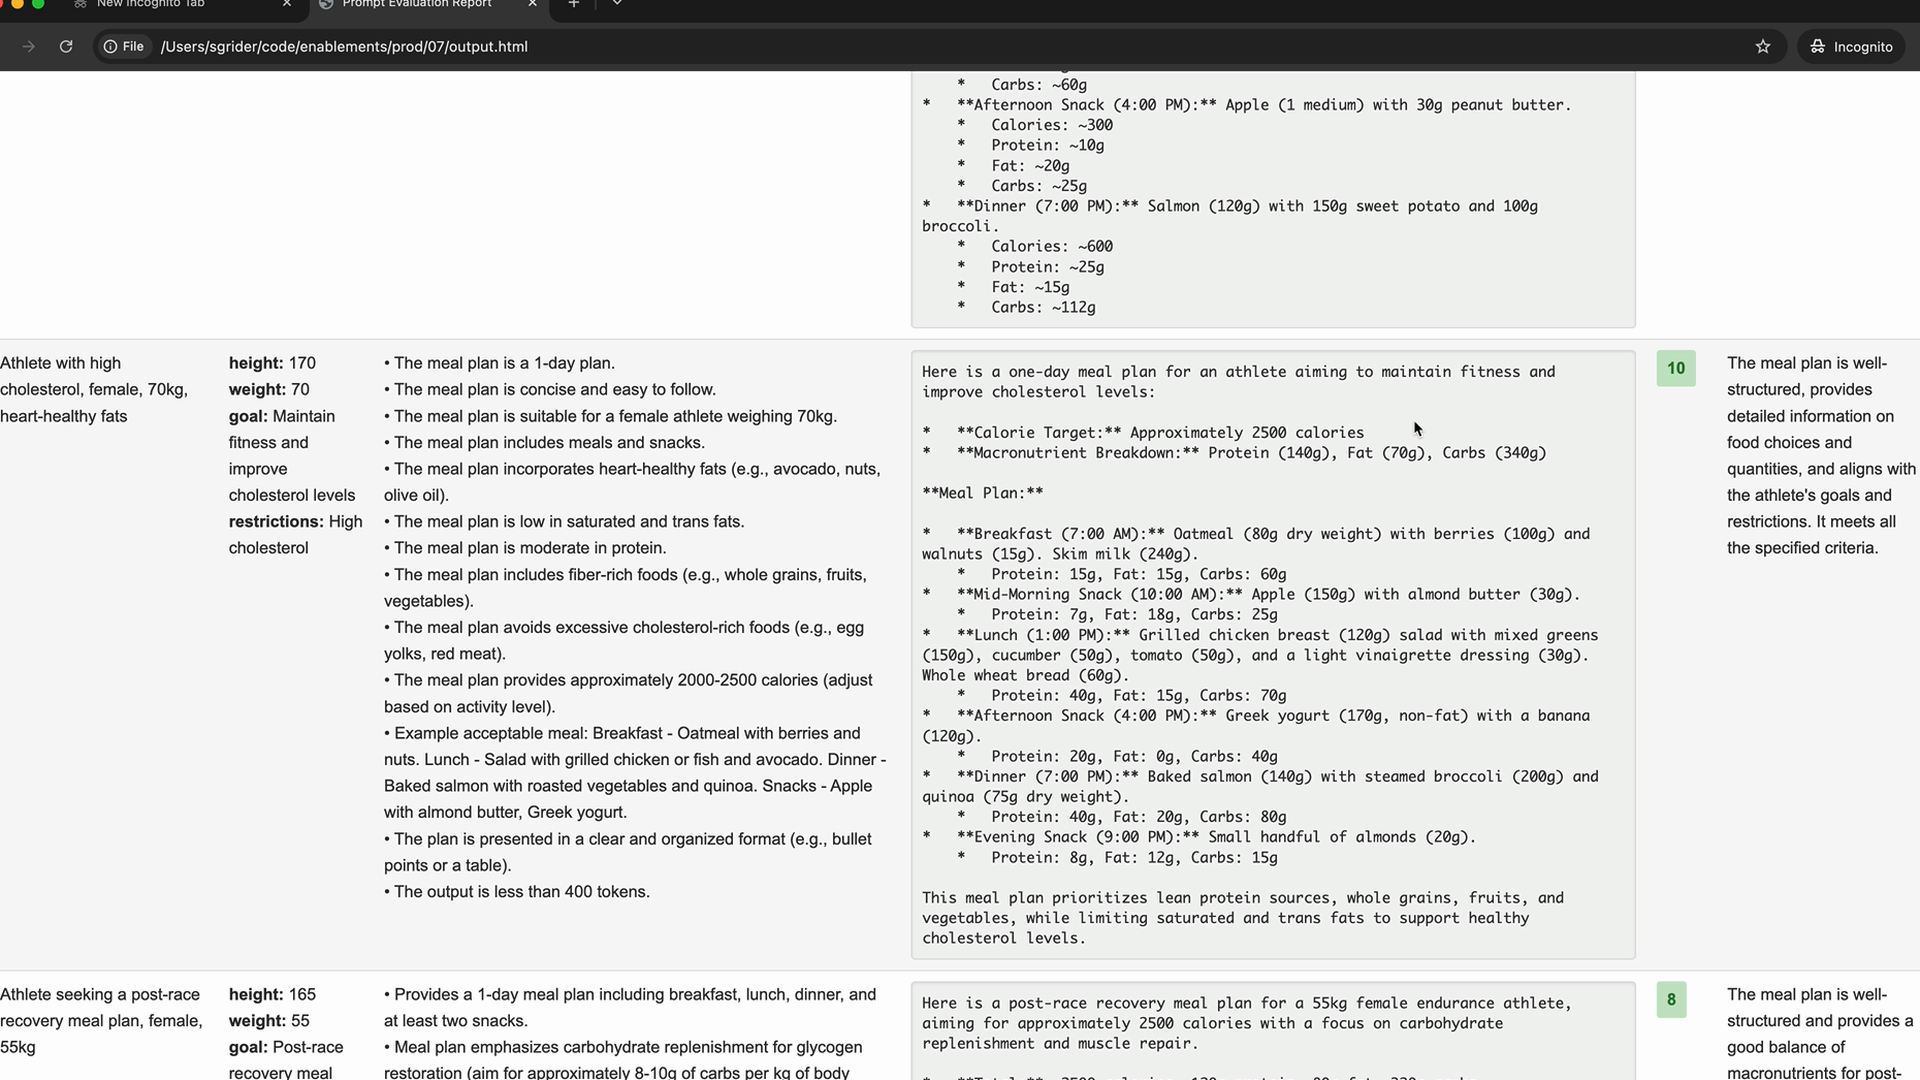

#### Adding Context to Examples
Don't just provide the input/output pair - explain why the output is good:

```
<ideal_output>
[Your example output here]
</ideal_output>

This example is well-structured, provides detailed information 
on food choices and quantities, and aligns with the athlete's 
goals and restrictions.
```

### Best Practices
* Always use XML tags to structure your examples clearly
* Be explicit about what you're showing: "Here is an example input with an ideal response"
* Include examples that address your most common failure cases
* Explain why your example outputs are considered ideal
* Keep examples relevant to your specific task